# Forecasting-Tools
## Static ARIMA Forecasting and Forecast Accuracy Evaluation

**Author:** Miguel A. Arranz, PhD  
**Date:** 8 October 2026  
**Updated:** 8 October 2026  
**Version:** 0.3.0

This notebook demonstrates the use of Forecasting-Tools for sequential one-step-ahead (static) ARIMA forecasting and forecast accuracy evaluation. It uses simulated data and integrates with ARIMA-Tools for model diagnostics. The examples are designed for students, instructors, and researchers interested in applied time series econometrics.

The version identifies this notebook, rather than a formal package release.

## 1. Introduction

| Package | Responsibilities |
|---|---|
| ARIMA-Tools | Estimation diagnostics, model properties, and dynamic forecasting; its documented fitting workflow uses Statsmodels |
| Forecasting-Tools | Static forecasting and forecast accuracy evaluation |

Forecasting-Tools does **not** depend internally on ARIMA-Tools. This particular notebook needs both repositories because it uses ARIMA-Tools diagnostics alongside its documented estimation workflow.

**Current interface clarification.** ARIMA-Tools 0.2.0 has no public fixed-order estimation function returning fitted results. Its [API documentation](https://github.com/maarranz/ARIMA-Tools/blob/main/docs/ARIMA_Tools_Documentation.qmd) explicitly uses `ARIMA(y, order=..., trend=...).fit()` from Statsmodels, followed by `at.coefficient_diagnostics(results)`. We follow that workflow rather than inventing an ARIMA-Tools estimator. `at.order_search(...)` returns a comparison table, not fitted results; `at.auto_arima(...)` returns a StatsForecast model, not the Statsmodels results required by `static_forecast`. The two fitted models below are `ARIMAResultsWrapper` objects and can be passed directly to Forecasting-Tools; no unwrapping or API changes are needed.

### Setup and portability

Clone [ARIMA-Tools](https://github.com/maarranz/ARIMA-Tools) alongside Forecasting-Tools:

```sh
git clone https://github.com/maarranz/ARIMA-Tools.git
```

Expected layout:

```text
parent/
├── ARIMA-Tools/arima_tools/
└── Forecasting-Tools/
    ├── forecasting_tools.py
    └── Notebooks/Forecasting_Tools_Demo.ipynb
```

Launch Jupyter from either `Forecasting-Tools/` or its `Notebooks/` directory and select a kernel with both packages' dependencies available (see setup below). The next cell locates the repository relative to the current working directory; it contains no machine-specific paths. Neither repository currently needs packaging infrastructure for this layout.

### Demonstration dependencies

The standard `forecasting_tools` environment now uses Python 3.13, pandas below 3, and StatsForecast 2.1 or newer. From the repository root, create the environment if it does not exist and register its kernel:

```sh
mamba env create -f environment.yml
mamba run -n forecasting_tools python -m ipykernel install --user --name forecasting_tools --display-name "Python (forecasting_tools)"
```

If the environment already exists, use it rather than running the creation command again. Select **Python (forecasting_tools)** in Jupyter. No separate demonstration environment or temporary dependency installation is required.

The public ARIMA-Tools diagnostics below do not call StatsForecast, but ARIMA-Tools 0.2.0 imports its automatic-selection functions unconditionally, creating an indirect import dependency. StatsForecast is included in the standard environment for this integration; the Forecasting-Tools API does not import it. The sibling-repository import strategy above works from both the repository root and `Notebooks/`.

In [1]:
from pathlib import Path
import sys

repository_root = next(
    (path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (path / "forecasting_tools.py").is_file()),
    None,
)
if repository_root is None:
    raise FileNotFoundError("Launch from Forecasting-Tools or its Notebooks directory.")
arima_repository = repository_root.parent / "ARIMA-Tools"
if not (arima_repository / "arima_tools" / "__init__.py").is_file():
    raise FileNotFoundError("Clone ARIMA-Tools alongside Forecasting-Tools; see Setup above.")
for path in (repository_root, arima_repository):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from statsmodels.tsa.arima.model import ARIMA, ARIMAResultsWrapper
import arima_tools as at
import forecasting_tools as ft

%matplotlib inline
plt.rcParams.update({"figure.figsize": (11, 4), "font.size": 11})
display(pd.Series({"ARIMA-Tools": at.__version__,
                   "NumPy": np.__version__, "pandas": pd.__version__}, name="Version"))

/opt/homebrew/Caskroom/miniforge/base/envs/forecasting_tools/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ARIMA-Tools    0.2.0
NumPy          2.5.3
pandas         2.3.3
Name: Version, dtype: object

## 2. Simulating an ARMA process

We generate a stationary, invertible ARMA(1,1):

\[
y_t-\mu=\phi(y_{t-1}-\mu)+\varepsilon_t+\theta\varepsilon_{t-1},
\qquad \varepsilon_t\stackrel{iid}{\sim}N(0,\sigma^2),
\]

with $\phi=0.7$, $\theta=0.4$, $\mu=100$, and $\sigma=2$. Both AR and MA roots lie outside the unit circle because $|\phi|<1$ and $|\theta|<1$. The plus sign on the MA term follows Statsmodels' convention. A burn-in of 500 observations reduces initialization effects before retaining 300 observations.

The first 250 observations are used for estimation; the last 50 are reserved for forecast evaluation. The fixed seed is chosen once, not searched to produce a desired ranking. A positive mean keeps this realization away from zero, making MAPE interpretable; a positive mean alone does not guarantee positive Gaussian observations. Dates are convenient regular labels for consecutive observation steps, not an assertion of calendar seasonality.

In [2]:
seed = 20261008
phi, theta, mean, innovation_sd = 0.7, 0.4, 100.0, 2.0
burn_in, sample_size, estimation_size = 500, 300, 250

def simulate_arma(seed):
    rng = np.random.default_rng(seed)
    innovations = rng.normal(0.0, innovation_sd, burn_in + sample_size)
    centered = np.zeros_like(innovations)
    for t in range(1, len(centered)):
        centered[t] = phi * centered[t - 1] + innovations[t] + theta * innovations[t - 1]
    return mean + centered[burn_in:]

observations = pd.Series(
    simulate_arma(seed),
    index=pd.date_range("2020-01-01", periods=sample_size, freq="D"),
    name="Simulated y",
)
estimation = observations.iloc[:estimation_size]
actual = observations.iloc[estimation_size:]
np.testing.assert_array_equal(observations.to_numpy(), simulate_arma(seed))
assert len(estimation) == 250 and len(actual) == 50
assert (observations > 0).all()
display(pd.Series({"Estimation observations": len(estimation),
                   "Evaluation observations": len(actual),
                   "Minimum observation": observations.min()}, name="Sample"))

Estimation observations    250.000000
Evaluation observations     50.000000
Minimum observation         86.275885
Name: Sample, dtype: float64

## 3. ARIMA estimation

Model 1 is the correctly specified ARMA(1,1), represented by `order=(1, 0, 1)`; Model 2 is an AR(1), `order=(1, 0, 0)`, omitting the moving-average component. We use only the estimation sample and a constant (`trend="c"`) for both.

For these stationary models, Statsmodels' `const` estimates the level mean $\mu$, not the recursion intercept $(1-\phi)\mu$. The AR(1) innovations $u_t$ need not be white noise when the omitted MA component matters. The correctly specified model need not outperform the simpler model in every finite sample.

As explained above, estimation follows ARIMA-Tools' documented Statsmodels fitting workflow. Its public `coefficient_diagnostics(results, confidence=0.95)` reports coefficient inference; `compare_models(*results, names=...)`, `is_causal(results)`, and `is_invertible(results)` provide concise model diagnostics. Training information criteria are distinct from out-of-sample forecast accuracy.

In [3]:
models = {
    "ARMA(1,1)": ARIMA(estimation, order=(1, 0, 1), trend="c").fit(),
    "AR(1)": ARIMA(estimation, order=(1, 0, 0), trend="c").fit(),
}
parameter_snapshot = {name: result.params.copy() for name, result in models.items()}
for result in models.values():
    assert isinstance(result, ARIMAResultsWrapper)
    assert result.nobs == estimation_size
    assert result.mle_retvals["converged"]

coefficients = pd.concat({
    name: at.coefficient_diagnostics(result).set_index("Coefficient")[
        ["Estimate", "Std. Error", "95% CI Lower", "95% CI Upper"]
    ] for name, result in models.items()
}, names=["Model", "Coefficient"])
display(coefficients.round(4))
model_summary = at.compare_models(*models.values(), names=list(models))[
    ["Order", "N", "Log Likelihood", "AIC", "BIC"]
]
model_summary["Causal"] = [at.is_causal(result) for result in models.values()]
model_summary["Invertible"] = [at.is_invertible(result) for result in models.values()]
display(model_summary.round(3))

Estimate  Std. Error  95% CI Lower  95% CI Upper
Model     Coefficient                                                  
ARMA(1,1) const         99.9006      0.7158       98.4977      101.3036
          ar.L1          0.7472      0.0476        0.6539        0.8405
          ma.L1          0.3384      0.0697        0.2018        0.4750
          sigma2         4.5214      0.4179        3.7022        5.3405
AR(1)     const         99.8922      0.8694       98.1883      101.5961
          ar.L1          0.8402      0.0317        0.7781        0.9022
          sigma2         4.8349      0.4245        4.0029        5.6670

,Order,N,Log Likelihood,AIC,BIC,Causal,Invertible
Model,,,,,,,
"ARMA(1,1)","(1, 0, 1)",250,-544.033,1096.066,1110.152,True,True
AR(1),"(1, 0, 0)",250,-552.330,1110.661,1121.225,True,True


## 4. Static forecasting

Static evaluation here means **sequential one-step-ahead prediction**:

1. Estimate parameters from the initial 250 observations.
2. Predict the next observation using the available information.
3. Observe its actual value.
4. Append that observation with `refit=False`, updating the information set.
5. Repeat for all 50 evaluation observations.

Parameters remain fixed throughout. Evaluation actuals are used only after their own prediction. By contrast, dynamic multi-step forecasts issued at the split propagate predicted values beyond that origin, without incorporating later actual observations. Static evaluation therefore represents repeated forecast decisions as new data arrive, rather than a single 50-step forecast issued initially.

`static_forecast(results, actual, level=0.95)` accepts a fitted nonseasonal Statsmodels ARIMA without user exogenous regressors. The finite evaluation Series must immediately continue its recognized training index. It returns `Actual`, `Forecast`, `Error`, `SE`, `Lower`, and `Upper`, indexed by evaluation dates. Errors are actual minus forecast. Intervals are conditional Gaussian prediction intervals and exclude parameter estimation uncertainty.

In [4]:
forecasts = {
    name: ft.static_forecast(result, actual, level=0.95)
    for name, result in models.items()
}
for name, frame in forecasts.items():
    assert len(frame) == 50 and frame.index.equals(actual.index)
    np.testing.assert_allclose(frame["Error"], frame["Actual"] - frame["Forecast"])
    np.testing.assert_allclose(frame["Actual"], actual)
    np.testing.assert_array_equal(models[name].params, parameter_snapshot[name])
    assert models[name].nobs == estimation_size

display(pd.concat({name: frame.head(4) for name, frame in forecasts.items()},
                  names=["Model", "Evaluation date"]).round(3))

Actual  Forecast  Error     SE   Lower    Upper
Model     Evaluation date                                                  
ARMA(1,1) 2020-09-07       100.409   100.432 -0.023  2.126  96.265  104.600
          2020-09-08        98.399   100.273 -1.873  2.126  96.105  104.440
          2020-09-09        99.902    98.145  1.757  2.126  93.978  102.313
          2020-09-10        98.400   100.496 -2.096  2.126  96.329  104.664
AR(1)     2020-09-07       100.409   100.124  0.285  2.199  95.815  104.434
          2020-09-08        98.399   100.326 -1.927  2.199  96.017  104.636
          2020-09-09        99.902    98.638  1.264  2.199  94.328  102.948
          2020-09-10        98.400    99.901 -1.501  2.199  95.591  104.210

## 5. Forecast accuracy

Let $e_t=y_t-\widehat y_t$ and let $n=50$ be the evaluation size:

\[
\mathrm{ME}=\frac1n\sum_t e_t,\quad
\mathrm{MAE}=\frac1n\sum_t|e_t|,\quad
\mathrm{MSE}=\frac1n\sum_t e_t^2,
\]
\[
\mathrm{RMSE}=\sqrt{\mathrm{MSE}},\qquad
\mathrm{MAPE}=\frac{100}{n}\sum_t\left|\frac{e_t}{y_t}\right|.
\]

- **ME** measures average signed error: positive values indicate underforecasting; negative values indicate overforecasting. Opposite errors can cancel, so small bias does not establish accuracy.
- **MAE** measures average absolute error in observation units.
- **MSE** measures squared error and penalizes large errors more heavily.
- **RMSE** also emphasizes large errors but has the same units as the forecast variable.
- **MAPE** measures relative magnitude as a percentage. It is undefined when any actual is zero and may be misleading near zero; its interpretation is strongest for positive data with a meaningful zero.

`forecast_accuracy(actual, forecast)` returns a Series ordered `ME`, `MAE`, `MSE`, `RMSE`, `MAPE`. Inputs must be numeric, finite, nonempty, and equal in length. Two Series must have matching indexes in the same order; there is no silent alignment, reordering, or missing-value removal. The combined function rejects zero actuals because it includes MAPE; the other four individual functions allow zeros.

In [5]:
accuracy = pd.DataFrame({
    name: ft.forecast_accuracy(actual, frame["Forecast"])
    for name, frame in forecasts.items()
})
accuracy.index.name = "Statistic"
display(accuracy.rename(index={"MAPE": "MAPE (%)"}).round(4))

,"ARMA(1,1)",AR(1)
Statistic,,
ME,-0.1498,-0.1345
MAE,1.3715,1.4392
MSE,2.5828,2.7828
RMSE,1.6071,1.6682
MAPE (%),1.3813,1.4492


In [6]:
# Interpret the computed table; no model ranking is hardcoded.
loss_lines = []
for statistic in ("MAE", "MSE", "RMSE", "MAPE"):
    row = accuracy.loc[statistic]
    units = "%" if statistic == "MAPE" else ""
    winner = "Both models (tie)" if row.nunique() == 1 else row.idxmin()
    loss_lines.append(
        f"- **{statistic}:** ARMA(1,1) = {row['ARMA(1,1)']:.4f}{units}; "
        f"AR(1) = {row['AR(1)']:.4f}{units}. Smaller realized loss: **{winner}**."
    )
mean_errors = accuracy.loc["ME"]
bias_winner = "Both models (tie)" if mean_errors.abs().nunique() == 1 else mean_errors.abs().idxmin()
loss_lines.append(
    f"- **ME:** ARMA(1,1) = {mean_errors['ARMA(1,1)']:.4f}; "
    f"AR(1) = {mean_errors['AR(1)']:.4f}. Smaller absolute ME: **{bias_winner}**."
)
display(Markdown("### Interpretation of the realized accuracy results\n\n" + "\n".join(loss_lines)))
display(Markdown(
    r"$\mathrm{ME}=\frac{1}{N}\sum_{t=1}^{N}e_t$ measures average signed forecast error. "
    "Positive and negative errors can cancel. ME is useful for examining bias, "
    "but is not a suitable standalone measure of accuracy. "
    "A smaller RMSE does not automatically establish statistically superior predictive performance. "
    "Formal comparisons, including MGN and DM tests, are planned for subsequent versions of Forecasting-Tools."
))

### Interpretation of the realized accuracy results

- **MAE:** ARMA(1,1) = 1.3715; AR(1) = 1.4392. Smaller realized loss: **ARMA(1,1)**.
- **MSE:** ARMA(1,1) = 2.5828; AR(1) = 2.7828. Smaller realized loss: **ARMA(1,1)**.
- **RMSE:** ARMA(1,1) = 1.6071; AR(1) = 1.6682. Smaller realized loss: **ARMA(1,1)**.
- **MAPE:** ARMA(1,1) = 1.3813%; AR(1) = 1.4492%. Smaller realized loss: **ARMA(1,1)**.
- **ME:** ARMA(1,1) = -0.1498; AR(1) = -0.1345. Smaller absolute ME: **AR(1)**.

$\mathrm{ME}=\frac{1}{N}\sum_{t=1}^{N}e_t$ measures average signed forecast error. Positive and negative errors can cancel. ME is useful for examining bias, but is not a suitable standalone measure of accuracy. A smaller RMSE does not automatically establish statistically superior predictive performance. Formal comparisons, including MGN and DM tests, are planned for subsequent versions of Forecasting-Tools.

In [7]:
# Two individual API calls, useful when only selected statistics are needed.
individual_examples = pd.DataFrame({
    name: {"RMSE": ft.rmse(actual, frame["Forecast"]),
           "MAPE (%)": ft.mape(actual, frame["Forecast"])}
    for name, frame in forecasts.items()
})
display(individual_examples.round(4))
for name, frame in forecasts.items():
    for statistic, function in (("ME", ft.me), ("MAE", ft.mae), ("MSE", ft.mse),
                                ("RMSE", ft.rmse), ("MAPE", ft.mape)):
        np.testing.assert_allclose(accuracy.loc[statistic, name], function(actual, frame["Forecast"]))

,"ARMA(1,1)",AR(1)
RMSE,1.6071,1.6682
MAPE (%),1.3813,1.4492


## 6. Comparing forecast performance

The next cell describes the realized ranking without imposing one. For ME, compare distance from zero rather than choosing the most negative value. Different measures can rank models differently: MAE weights absolute errors linearly, RMSE emphasizes larger errors, and MAPE gives more weight to errors at smaller actual values. MSE and RMSE always give the same ranking because the square root is increasing.

A lower RMSE does **not** automatically establish a statistically significant predictive accuracy advantage. Finite evaluation samples, estimation uncertainty, and dependence among loss differences matter. These are descriptive comparisons, not formal hypothesis tests. Formal comparison tests will be demonstrated separately once implemented.

In [8]:
ranking = pd.Series({
    "Absolute ME": accuracy.loc["ME"].abs().idxmin(),
    **{statistic: accuracy.loc[statistic].idxmin()
       for statistic in ["MAE", "MSE", "RMSE", "MAPE"]},
}, name="Smaller realized loss")
display(ranking)
rmse_difference = accuracy.loc["RMSE", "AR(1)"] - accuracy.loc["RMSE", "ARMA(1,1)"]
winner = accuracy.loc["RMSE"].idxmin()
display(Markdown(
    f"In this fixed-seed simulation, **{winner}** has the smaller evaluation RMSE. "
    f"AR(1) minus ARMA(1,1) RMSE is **{rmse_difference:.4f}** observation units. "
    "The ranking is a realized sample outcome, not proof of a population advantage."
))

Absolute ME        AR(1)
MAE            ARMA(1,1)
MSE            ARMA(1,1)
RMSE           ARMA(1,1)
MAPE           ARMA(1,1)
Name: Smaller realized loss, dtype: object

In this fixed-seed simulation, **ARMA(1,1)** has the smaller evaluation RMSE. AR(1) minus ARMA(1,1) RMSE is **0.0611** observation units. The ranking is a realized sample outcome, not proof of a population advantage.

## 7. Graphical analysis

Four figures show the simulation and split, the sequential forecasts, their signed errors, and two magnitude measures. Line styles distinguish the models as well as color. The second figure includes the ARMA model's conditional 95% interval for context; intervals for both models are available in the tables above.

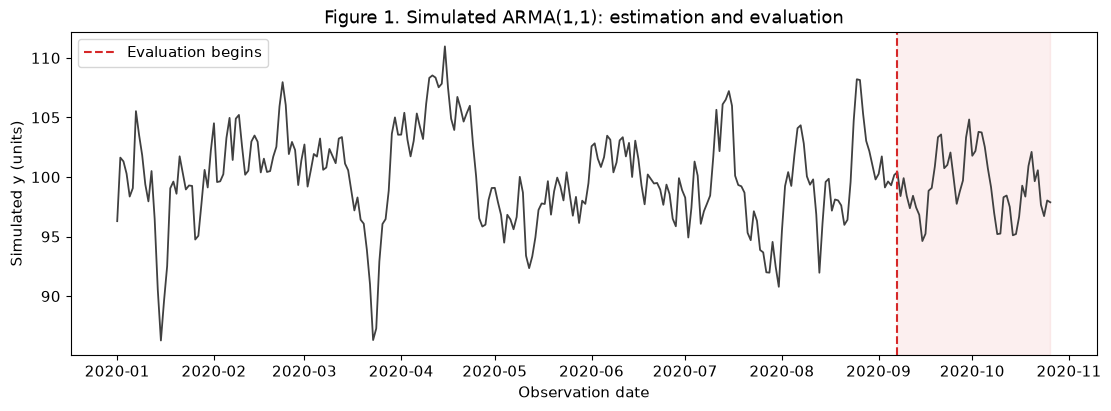

In [9]:
fig, ax = plt.subplots(layout="constrained")
ax.plot(observations.index, observations, color="0.25", linewidth=1.3)
ax.axvline(actual.index[0], color="tab:red", linestyle="--", label="Evaluation begins")
ax.axvspan(actual.index[0], actual.index[-1], color="tab:red", alpha=0.07)
ax.set(title="Figure 1. Simulated ARMA(1,1): estimation and evaluation",
       xlabel="Observation date", ylabel="Simulated y (units)")
ax.legend()
plt.show()

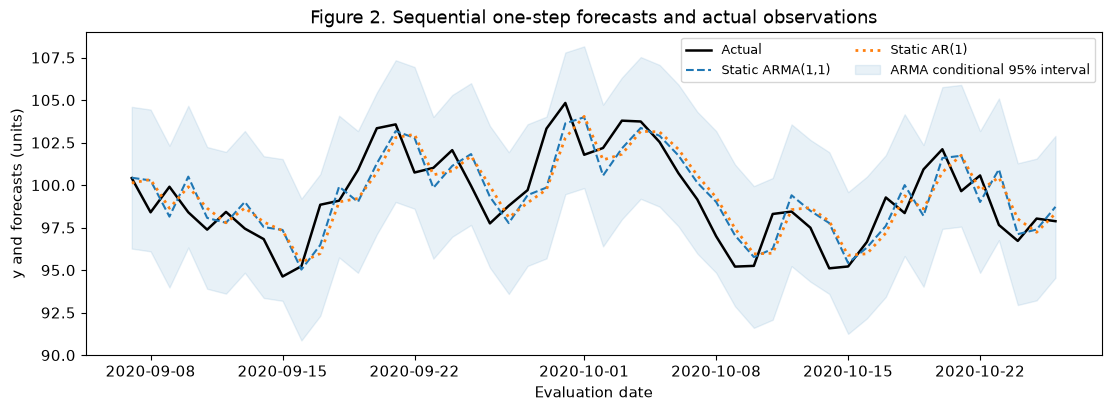

In [10]:
fig, ax = plt.subplots(layout="constrained")
ax.plot(actual.index, actual, color="black", linewidth=1.8, label="Actual")
ax.plot(actual.index, forecasts["ARMA(1,1)"]["Forecast"],
        color="tab:blue", linestyle="--", label="Static ARMA(1,1)")
ax.plot(actual.index, forecasts["AR(1)"]["Forecast"],
        color="tab:orange", linestyle=":", linewidth=2, label="Static AR(1)")
ax.fill_between(actual.index, forecasts["ARMA(1,1)"]["Lower"],
                forecasts["ARMA(1,1)"]["Upper"], color="tab:blue", alpha=0.1,
                label="ARMA conditional 95% interval")
ax.set(title="Figure 2. Sequential one-step forecasts and actual observations",
       xlabel="Evaluation date", ylabel="y and forecasts (units)")
ax.legend(fontsize=9, ncol=2)
plt.show()

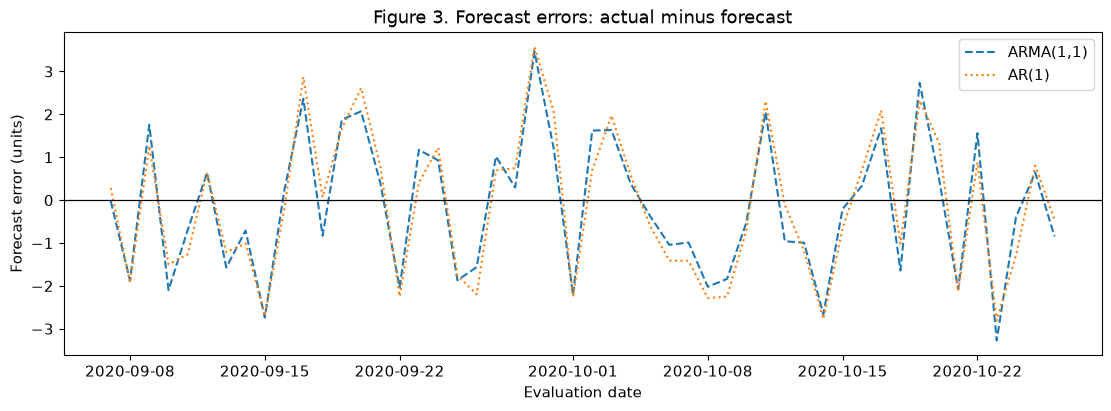

In [11]:
fig, ax = plt.subplots(layout="constrained")
for name, color, style in [("ARMA(1,1)", "tab:blue", "--"), ("AR(1)", "tab:orange", ":")]:
    ax.plot(actual.index, forecasts[name]["Error"], color=color, linestyle=style, label=name)
ax.axhline(0, color="black", linewidth=0.9)
ax.set(title="Figure 3. Forecast errors: actual minus forecast",
       xlabel="Evaluation date", ylabel="Forecast error (units)")
ax.legend()
plt.show()

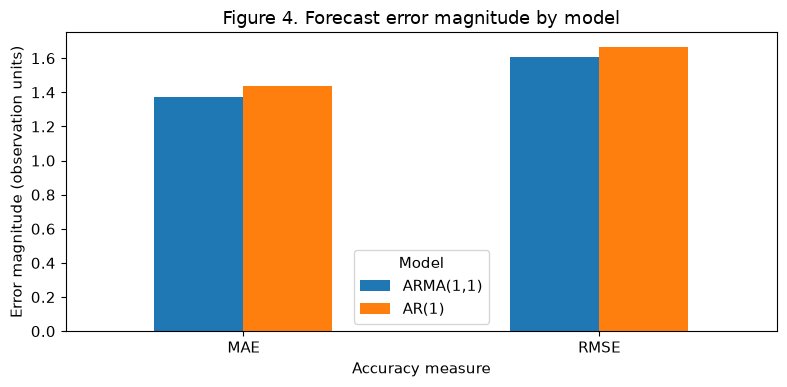

In [12]:
ax = accuracy.loc[["MAE", "RMSE"]].plot.bar(
    color=["tab:blue", "tab:orange"], rot=0, figsize=(8, 4)
)
ax.set(title="Figure 4. Forecast error magnitude by model",
       xlabel="Accuracy measure", ylabel="Error magnitude (observation units)")
ax.legend(title="Model")
ax.figure.tight_layout()
plt.show()

## 8. Forecast Unbiasedness

We apply both unbiasedness procedures to the same 50 one-step forecasts. The **mean-error test** examines
\[
H_0:E(e_t)=0,\qquad e_t=y_t-\widehat y_t.
\]
Positive mean errors indicate underforecasting and negative ones overforecasting. The **Mincer–Zarnowitz test** estimates
\[
y_t=a+b\widehat y_t+u_t,\qquad H_0:a=0,\quad b=1,
\]
and tests both restrictions jointly, rather than separately.

We use HAC inference at 5%: a normal statistic for mean error and chi-square with two restrictions for joint calibration. Bartlett weights and the API's automatic bandwidth are used without a small-sample multiplier. Coefficient intervals have 95% marginal coverage. With only 50 observations, asymptotic approximations and power deserve caution. Failure to reject either null does not establish forecast optimality.

In [13]:
significance_level = 0.05
mean_error_results = {
    name: ft.unbiasedness_test(actual, frame["Forecast"], method="mean_error",
                               cov_type="HAC", alpha=significance_level)
    for name, frame in forecasts.items()
}
mincer_zarnowitz_results = {
    name: ft.unbiasedness_test(actual, frame["Forecast"], method="mincer_zarnowitz",
                               cov_type="HAC", alpha=significance_level)
    for name, frame in forecasts.items()
}

def diagnostic_decision(result):
    return "Reject H0" if result["reject_null"] else "Do not reject H0"

mean_error_table = pd.DataFrame({
    name: {"Mean error": result["parameters"]["intercept"],
           "SE": result["standard_errors"]["intercept"],
           "z statistic": result["statistic"], "p-value": result["pvalue"],
           "HAC lags": result["maxlags"], "Decision (5%)": diagnostic_decision(result)}
    for name, result in mean_error_results.items()
}).T
mincer_zarnowitz_table = pd.DataFrame({
    name: {"Intercept": result["parameters"]["intercept"],
           "Slope": result["parameters"]["slope"],
           "Joint chi-square": result["statistic"], "df": result["df"],
           "p-value": result["pvalue"], "HAC lags": result["maxlags"],
           "Decision (5%)": diagnostic_decision(result)}
    for name, result in mincer_zarnowitz_results.items()
}).T
for title, table in [("Mean-error test", mean_error_table),
                     ("Mincer–Zarnowitz joint calibration", mincer_zarnowitz_table)]:
    display(Markdown(f"### {title}"))
    display(table.round(4))

### Mean-error test

,Mean error,SE,z statistic,p-value,HAC lags,Decision (5%)
"ARMA(1,1)",-0.149829,0.209781,-0.714217,0.475093,3,Do not reject H0
AR(1),-0.134505,0.244787,-0.549476,0.582679,3,Do not reject H0


### Mincer–Zarnowitz joint calibration

,Intercept,Slope,Joint chi-square,df,p-value,HAC lags,Decision (5%)
"ARMA(1,1)",9.191565,0.906061,2.170701,2,0.337783,3,Do not reject H0
AR(1),8.192825,0.916246,1.691281,2,0.429282,3,Do not reject H0


## 9. Weak Forecast Efficiency

For optimal one-step-ahead squared-error forecasts under suitable information assumptions, forecast errors should be serially uncorrelated. These are sequential one-step forecasts, so we set $h=1$ and use Ljung–Box through lag 10, with 10 diagnostic degrees of freedom. No MA model is fitted and no multistep forecasting is introduced.

The sample ACF visualizes the same errors. Approximate pointwise 95% bands are descriptive, not simultaneous bands or substitutes for the joint portmanteau test. Ljung–Box centers the errors, so it does not test mean bias. **Failure to reject residual serial correlation does not establish forecast optimality.** Uncorrelatedness does not imply independence, and small-sample or heteroskedasticity effects can affect the reference distribution.

In [14]:
diagnostic_lags = 10
weak_efficiency_results = {
    name: ft.weak_efficiency_test(actual, frame["Forecast"], h=1,
                                 lags=diagnostic_lags, alpha=significance_level)
    for name, frame in forecasts.items()
}
weak_efficiency_table = pd.DataFrame({
    name: {"Ljung–Box Q": result["statistic"], "df": result["df"],
           "p-value": result["pvalue"], "Decision (5%)": diagnostic_decision(result)}
    for name, result in weak_efficiency_results.items()
}).T
display(weak_efficiency_table.round(4))

,Ljung–Box Q,df,p-value,Decision (5%)
"ARMA(1,1)",3.730484,10,0.958687,Do not reject H0
AR(1),5.216193,10,0.876276,Do not reject H0


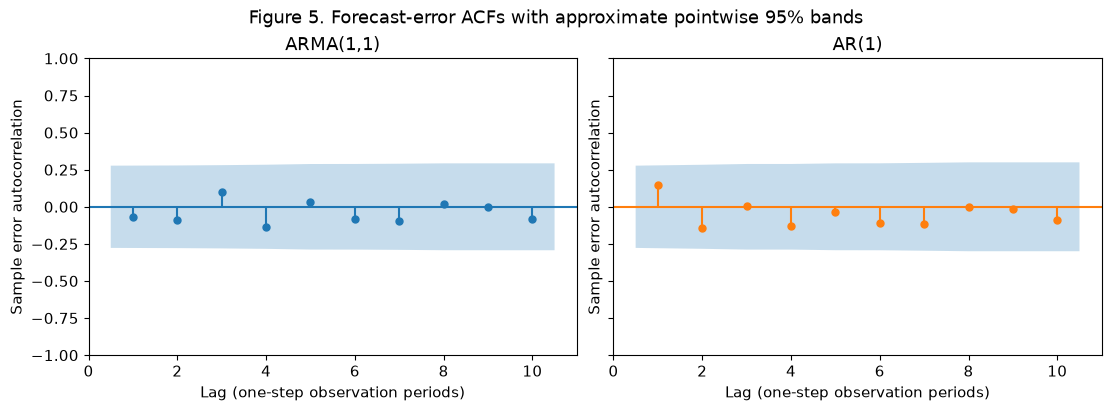

In [15]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, layout="constrained")
for ax, (name, frame), color in zip(axes, forecasts.items(), ["tab:blue", "tab:orange"]):
    plot_acf(frame["Error"], ax=ax, lags=diagnostic_lags, zero=False,
             alpha=significance_level, fft=False, color=color,
             vlines_kwargs={"colors": color}, title=name)
    ax.set(xlabel="Lag (one-step observation periods)", ylabel="Sample error autocorrelation")
    ax.set_ylim(-1, 1)
fig.suptitle("Figure 5. Forecast-error ACFs with approximate pointwise 95% bands")
plt.show()

## 10. Forecast Orthogonality

When forecasting $y_t$, the most recently observed value $y_{t-1}$ is available at the forecast origin. We construct it from the **complete simulated series before selecting evaluation dates**. Thus the first evaluation row uses the last estimation observation, rather than losing that row or using $y_t$ itself. Later rows use actual values already observed before the next forecast.

\[
e_t=a+\gamma y_{t-1}+u_t,\qquad H_0:a=0,\quad\gamma=0.
\]

The intercept and information coefficient are tested **jointly**, using HAC chi-square inference. Dates in the information Series label the forecast targets solely to pair rows correctly; the values refer to the preceding origin. `orthogonality_test` does not shift or align variables itself. Using target-date or future information would introduce look-ahead bias. This is an orthogonality test relative to one specified variable and a linear functional form, not a test against every possible information set.

In [16]:
origin_information = observations.shift(1).loc[actual.index].rename("previous_observation")
origin_dates = observations.index[estimation_size - 1:-1]
np.testing.assert_array_equal(origin_information.to_numpy(),
                               observations.iloc[estimation_size - 1:-1].to_numpy())
assert origin_information.index.equals(actual.index)
assert origin_information.iloc[0] == estimation.iloc[-1]
assert (origin_dates < actual.index).all()
assert not origin_information.isna().any()

display(pd.DataFrame({"Forecast target": actual.index, "Forecast origin": origin_dates,
                      "Origin-available value": origin_information.to_numpy()}).head(4))
orthogonality_results = {
    name: ft.orthogonality_test(actual, frame["Forecast"], origin_information,
                               h=1, cov_type="HAC", alpha=significance_level)
    for name, frame in forecasts.items()
}
orthogonality_table = pd.DataFrame({
    name: {"Intercept": result["parameters"]["intercept"],
           "Previous-value coefficient": result["parameters"]["previous_observation"],
           "Joint chi-square": result["statistic"], "df": result["df"],
           "p-value": result["pvalue"], "HAC lags": result["maxlags"],
           "Decision (5%)": diagnostic_decision(result)}
    for name, result in orthogonality_results.items()
}).T
display(orthogonality_table.round(4))

,Forecast target,Forecast origin,Origin-available value
0,2020-09-07,2020-09-06,100.168531
1,2020-09-08,2020-09-07,100.409063
2,2020-09-09,2020-09-08,98.399484
3,2020-09-10,2020-09-09,99.902125


,Intercept,Previous-value coefficient,Joint chi-square,df,p-value,HAC lags,Decision (5%)
"ARMA(1,1)",8.158925,-0.083642,2.504916,2,0.285801,3,Do not reject H0
AR(1),6.855497,-0.070366,1.691281,2,0.429282,3,Do not reject H0


## 11. Diagnostic Summary

The compact table reports p-values for the four distinct null hypotheses. Read the decisions at 5% alongside the magnitude measures above. These diagnostics do not test whether one model's predictive accuracy is significantly better than the other's. Several diagnostics are displayed without multiplicity adjustment; their findings are exploratory, and small p-values or nonrejections need to be considered with the assumptions and evaluation sample size.

For the fitted AR(1), the one-step forecast is an affine function of the previous observation. Its Mincer–Zarnowitz and lagged-value orthogonality regressions therefore span the same information and test equivalent joint restrictions (provided the AR coefficient is nonzero). Their matching statistics are not independent confirmations of performance. In contrast, the ARMA forecast also incorporates the filtered innovation, so these two information spans need not coincide.

In [17]:
diagnostic_results = {
    "Mean-error test": mean_error_results,
    "Mincer–Zarnowitz": mincer_zarnowitz_results,
    "Weak efficiency": weak_efficiency_results,
    "Orthogonality": orthogonality_results,
}
diagnostic_pvalues = pd.DataFrame({
    label: {name: result["pvalue"] for name, result in results.items()}
    for label, results in diagnostic_results.items()
}).T
diagnostic_pvalues.index.name = "Diagnostic"
display(diagnostic_pvalues.round(4))
interpretation_lines = []
for name in models:
    rejected = [label for label, results in diagnostic_results.items() if results[name]["reject_null"]]
    if rejected:
        interpretation_lines.append(
            f"- **{name}:** at 5%, reject the null for {', '.join(rejected)}. "
            "These findings concern the stated restrictions, not a complete optimality assessment."
        )
    else:
        interpretation_lines.append(
            f"- **{name}:** none of these four null hypotheses is rejected at 5%. "
            "This does not establish forecast optimality or exclude omitted/nonlinear predictability."
        )
display(Markdown("\n".join(interpretation_lines)))
display(Markdown(
    "A correctly specified ARMA model need not dominate an AR model in every finite sample. "
    "Accuracy rankings and diagnostic decisions answer different questions; "
    "nonrejection should not be interpreted as evidence that the tested restrictions hold exactly."
))

,"ARMA(1,1)",AR(1)
Diagnostic,,
Mean-error test,0.4751,0.5827
Mincer–Zarnowitz,0.3378,0.4293
Weak efficiency,0.9587,0.8763
Orthogonality,0.2858,0.4293


- **ARMA(1,1):** none of these four null hypotheses is rejected at 5%. This does not establish forecast optimality or exclude omitted/nonlinear predictability.
- **AR(1):** none of these four null hypotheses is rejected at 5%. This does not establish forecast optimality or exclude omitted/nonlinear predictability.

A correctly specified ARMA model need not dominate an AR model in every finite sample. Accuracy rankings and diagnostic decisions answer different questions; nonrejection should not be interpreted as evidence that the tested restrictions hold exactly.

### Diagnostic execution checks

The following checks compare displayed statistics with direct API calls, verify the unchanged evaluation sample and error definition, and ensure every numerical diagnostic is finite. Timing assertions above explicitly verify the origin information. The original sequential-filtering checks remain below.

In [18]:
for name, frame in forecasts.items():
    direct_results = {
        "Mean-error test": ft.unbiasedness_test(actual, frame["Forecast"], method="mean_error"),
        "Mincer–Zarnowitz": ft.unbiasedness_test(actual, frame["Forecast"], method="mincer_zarnowitz"),
        "Weak efficiency": ft.weak_efficiency_test(actual, frame["Forecast"], h=1, lags=diagnostic_lags),
        "Orthogonality": ft.orthogonality_test(actual, frame["Forecast"], origin_information, h=1),
    }
    assert len(frame) == 50 and frame.index.equals(actual.index)
    np.testing.assert_allclose(frame["Error"], actual - frame["Forecast"])
    for label, direct in direct_results.items():
        stored = diagnostic_results[label][name]
        np.testing.assert_allclose([stored["statistic"], stored["pvalue"]],
                                   [direct["statistic"], direct["pvalue"]])
        assert stored["reject_null"] == direct["reject_null"]
        assert np.isfinite([stored["statistic"], stored["pvalue"]]).all()
        if "parameters" in stored:
            assert np.isfinite(list(stored["parameters"].values())).all()
            assert np.isfinite(list(stored["standard_errors"].values())).all()
            assert np.isfinite(list(stored["confidence_intervals"].values())).all()
print("All unbiasedness, efficiency, orthogonality timing, and diagnostic consistency checks passed.")

All unbiasedness, efficiency, orthogonality timing, and diagnostic consistency checks passed.


## 12. Forecast Comparison — Morgan–Granger–Newbold

We compare **ARMA(1,1)**, the correctly specified data-generating model, with the simpler, potentially misspecified **AR(1)** model using the same held-out observations and fixed-parameter forecasts.

Define the errors and MGN transformations as
\[
e_{1t}=y_t-\widehat y_{1t},\qquad e_{2t}=y_t-\widehat y_{2t},\qquad
u_t=e_{1t}+e_{2t},\qquad v_t=e_{1t}-e_{2t}.
\]
Estimate
\[
u_t=\alpha+\beta v_t+\varepsilon_t,\qquad H_0:\beta=0.
\]
The intercept is unrestricted. The slope tests the covariance restriction between the sum and difference of errors: their covariance equals the difference of error variances. **Under the assumption that both forecast errors have zero population means**, this corresponds to equality of mean squared forecast errors. Small sample mean errors do not establish that assumption; we report both sample means below.

The default HAC inference uses Bartlett weights and the API's automatic bandwidth. The reported signed statistic is a normal z statistic for HAC inference and a Student t statistic with n−2 degrees of freedom for conventional inference.

In [19]:
forecast_arma = forecasts["ARMA(1,1)"]["Forecast"]
forecast_ar = forecasts["AR(1)"]["Forecast"]
mgn_hac = ft.mgn_test(actual, forecast_arma, forecast_ar, cov_type="HAC")

mgn_details = pd.Series({
    "Correlation of u and v": mgn_hac["correlation"],
    "Estimated slope": mgn_hac["parameters"]["slope"],
    "HAC standard error": mgn_hac["standard_errors"]["slope"],
    "z statistic": mgn_hac["statistic"],
    "p-value": mgn_hac["pvalue"],
    "HAC bandwidth": mgn_hac["maxlags"],
}, name="MGN (HAC)")
display(mgn_details.round(4))
display(Markdown(f"**Decision at 5%:** {diagnostic_decision(mgn_hac)}."))
mgn_error_summary = pd.DataFrame({
    "Mean forecast error": [mgn_hac["mean_errors"]["model1"], mgn_hac["mean_errors"]["model2"]],
    "MSE": [mgn_hac["mse"]["model1"], mgn_hac["mse"]["model2"]],
}, index=["ARMA(1,1)", "AR(1)"])
display(mgn_error_summary.round(4))

Correlation of u and v   -0.1346
Estimated slope          -0.9244
HAC standard error        0.7386
z statistic              -1.2515
p-value                   0.2107
HAC bandwidth             3.0000
Name: MGN (HAC), dtype: float64

**Decision at 5%:** Do not reject H0.

,Mean forecast error,MSE
"ARMA(1,1)",-0.1498,2.5828
AR(1),-0.1345,2.7828


### Conventional and HAC inference

Both procedures estimate the same intercept and slope, but use different covariance estimators and reference distributions. HAC permits heteroskedasticity and serial dependence under its regularity conditions; its standard error can be smaller or larger than the conventional standard error. The comparison uses the existing simulation without selecting a seed to obtain significance.

In [20]:
mgn_conventional = ft.mgn_test(actual, forecast_arma, forecast_ar, cov_type="nonrobust")
mgn_results = {"Conventional": mgn_conventional, "HAC": mgn_hac}
mgn_comparison = pd.DataFrame({label: {
    "Slope": result["parameters"]["slope"],
    "Standard error": result["standard_errors"]["slope"],
    "Statistic": result["statistic"],
    "Reference distribution": result["distribution"],
    "p-value": result["pvalue"],
    "Decision (5%)": diagnostic_decision(result),
} for label, result in mgn_results.items()}).T
display(mgn_comparison)
assert mgn_conventional["parameters"] == mgn_hac["parameters"]
for label, result in mgn_results.items():
    direct = ft.mgn_test(actual, forecast_arma, forecast_ar, cov_type=result["cov_type"])
    assert direct == result
    assert np.isclose(result["mse"]["model1"], ft.mse(actual, forecast_arma))
    assert np.isclose(result["mse"]["model2"], ft.mse(actual, forecast_ar))
    assert np.isclose(result["mean_errors"]["model1"], ft.me(actual, forecast_arma))
    assert np.isclose(result["mean_errors"]["model2"], ft.me(actual, forecast_ar))
classical_t = mgn_conventional["correlation"] * np.sqrt(
    (len(actual) - 2) / (1 - mgn_conventional["correlation"] ** 2))
assert np.isclose(classical_t, mgn_conventional["statistic"])
print("MGN direct API, descriptive measures, and classical correlation formula checks passed.")

,Slope,Standard error,Statistic,Reference distribution,p-value,Decision (5%)
Conventional,-0.924363,0.982249,-0.941068,t,0.351382,Do not reject H0
HAC,-0.924363,0.738589,-1.251527,normal,0.210742,Do not reject H0


MGN direct API, descriptive measures, and classical correlation formula checks passed.


In [21]:
smaller_mse_model = mgn_error_summary["MSE"].idxmin()
mse_gap = abs(mgn_hac["mse_difference"])
relative_gap = 100 * mse_gap / mgn_error_summary["MSE"].max()
display(Markdown(
    f"**Observed comparison:** Conventional inference gives p = {mgn_conventional['pvalue']:.4f} "
    f"({diagnostic_decision(mgn_conventional)}); HAC inference gives p = {mgn_hac['pvalue']:.4f} "
    f"({diagnostic_decision(mgn_hac)}), at the 5% level. **{smaller_mse_model}** has the smaller "
    f"sample MSE. The absolute MSE gap is {mse_gap:.4f}, or {relative_gap:.2f}% of the larger MSE. "
    "These are realized differences in this evaluation sample, not guarantees of future performance."
))

**Observed comparison:** Conventional inference gives p = 0.3514 (Do not reject H0); HAC inference gives p = 0.2107 (Do not reject H0), at the 5% level. **ARMA(1,1)** has the smaller sample MSE. The absolute MSE gap is 0.2000, or 7.19% of the larger MSE. These are realized differences in this evaluation sample, not guarantees of future performance.

### Interpretation and limitations

Statistical significance concerns evidence against the null under the test's assumptions. Economic significance concerns whether the forecast improvement matters for the decision, its costs, and the relevant loss function; a p-value alone cannot answer that question. Failure to reject does not establish equal accuracy: a small evaluation sample may have limited power.

A larger p-value in the earlier diagnostic tests does not imply better forecasts. Those tests assess particular restrictions, whereas sample MSE measures realized squared error magnitude. Neither nonrejection of diagnostics nor the MGN comparison establishes forecast optimality.

**MGN and Diebold–Mariano are distinct:** MGN tests the covariance restriction using transformed errors, with an equal-MSFE interpretation under zero population mean errors. DM will test equality of expected losses directly. DM is not implemented or called in this notebook.

## 13. Interpretation and conclusions

This demonstration connects three distinct operations. **Estimation** learns parameters using 250 training observations, following the fitting workflow documented by ARIMA-Tools and using its public diagnostics. **Static forecasting** holds those parameters fixed while updating the information set with each newly observed actual. **Accuracy evaluation** summarizes the resulting 50 held-out forecast errors using signed bias and magnitude measures.

The comparison table and generated ranking describe this single simulation. A correctly specified model is a useful benchmark, but parameter uncertainty and finite samples can give a simpler model competitive realized forecasts. **Statistical tests of forecast performance** ask different questions from descriptive error summaries; the added diagnostics examine bias, serial restrictions, and specified-information orthogonality, while the MGN section examines a pairwise covariance restriction.

Unbiasedness and efficiency procedures are now illustrated above. The Morgan–Granger–Newbold comparison is also illustrated above. Subsequent versions of Forecasting-Tools are intended to provide DM and forecast encompassing tests. This notebook does not call unimplemented functions. Re-run all cells in a fresh kernel to reproduce the simulation and figures; numerical optimization may show tiny differences across software versions.

### Execution checks

The final cell verifies the sequential predictions against a separate single-pass fixed-parameter filter of the full history. Although that check filters the whole series, its one-step predictions use only prior observations; it does not use smoothed states. It also verifies that changing later actuals cannot alter earlier forecasts. These checks evaluate notebook integrity, not statistical significance.

In [22]:
for name, result in models.items():
    oracle = result.model.clone(observations).filter(parameter_snapshot[name])
    one_step = oracle.get_prediction(start=estimation_size, end=sample_size - 1, dynamic=False)
    np.testing.assert_allclose(forecasts[name]["Forecast"], one_step.predicted_mean,
                               rtol=1e-8, atol=1e-8)
    np.testing.assert_allclose(forecasts[name]["SE"], one_step.se_mean, rtol=1e-8, atol=1e-8)
    changed_actual = actual.copy()
    changed_actual.iloc[10:] += 5
    changed_forecasts = ft.static_forecast(result, changed_actual)
    np.testing.assert_allclose(forecasts[name]["Forecast"].iloc[:11],
                               changed_forecasts["Forecast"].iloc[:11])
print("All reproducibility, compatibility, sample, error, accuracy, and sequential forecast checks passed.")

All reproducibility, compatibility, sample, error, accuracy, and sequential forecast checks passed.
